In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
data = pd.read_csv("saudi_pro_league.csv")
data.head()


,match_date,league_name,matchid,home_team,away_team,home_probability_win,draw_probability,away_probability_win,home_goals,away_goals,...,away_interceptions,away_blocks,away_clearances,away_keeper_save,away_duels_won,away_geround_duels_won,away_aerial_duels_won,away_successful_dribbles,away_yellow_cards,away_red_cards
0,2023-08-11,Saudi Professional League,4256017,Al Ahli,Al Hazem,0.834670,0.108706,0.056624,3,1,...,8,3,8,4,45,40,44,50,2,0
1,2023-08-12,Saudi Professional League,4256031,Al Taee,Damac FC,0.456989,0.270968,0.272043,1,0,...,5,2,7,1,50,49,45,70,5,0
2,2023-08-12,Saudi Professional League,4256030,Al-Fayha,Al Khaleej,0.446527,0.265711,0.287762,3,1,...,7,1,11,0,51,60,57,67,1,0
3,2023-08-13,Saudi Professional League,4256029,Al Fateh FC,Al-Taawoun,0.479419,0.241525,0.279056,1,1,...,7,3,16,3,43,53,62,57,2,0
4,2023-08-13,Saudi Professional League,4256028,Al Riyadh,Al-Wehda,0.450584,0.231907,0.317510,1,0,...,10,0,8,2,54,55,38,46,1,0


In [13]:
data.describe()


,matchid,home_probability_win,draw_probability,away_probability_win,home_goals,away_goals,ftr,home_ball_possession,home_total_shots,home_shots_on_target,...,away_interceptions,away_blocks,away_clearances,away_keeper_save,away_duels_won,away_geround_duels_won,away_aerial_duels_won,away_successful_dribbles,away_yellow_cards,away_red_cards
count,2.340000e+02,234.000000,234.000000,234.000000,234.000000,234.000000,234.000000,234.000000,234.000000,234.000000,...,234.000000,234.000000,234.000000,234.000000,234.000000,234.000000,234.000000,234.000000,234.000000,234.000000
mean,4.256173e+06,0.442416,0.238222,0.319362,1.576923,1.470085,0.923077,50.551282,12.769231,4.555556,...,8.645299,3.085470,17.747863,3.038462,45.649573,50.025641,48.696581,51.974359,1.927350,0.132479
std,9.995490e+01,0.230675,0.091951,0.234598,1.366546,1.429743,0.880439,11.407001,5.133220,2.466756,...,3.530103,2.125151,9.080972,1.869858,8.453169,6.210833,14.345440,13.528835,1.249489,0.339737
min,4.256017e+06,0.074247,0.067715,0.000291,0.000000,0.000000,0.000000,24.000000,2.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,25.000000,35.000000,13.000000,15.000000,0.000000,0.000000
25%,4.256075e+06,0.231630,0.154576,0.120282,1.000000,0.000000,0.000000,42.000000,9.000000,3.000000,...,6.000000,1.000000,11.000000,2.000000,40.000000,45.000000,40.000000,44.000000,1.000000,0.000000
50%,4.256206e+06,0.443289,0.251973,0.242296,1.000000,1.000000,1.000000,51.000000,12.000000,4.000000,...,8.000000,3.000000,16.000000,3.000000,45.000000,51.000000,47.000000,52.000000,2.000000,0.000000
75%,4.256264e+06,0.613786,0.319221,0.487906,2.000000,2.000000,2.000000,59.000000,16.000000,6.000000,...,11.000000,4.000000,23.000000,4.000000,51.000000,55.000000,59.000000,60.000000,3.000000,0.000000
max,4.256322e+06,0.873399,0.408509,0.826992,7.000000,9.000000,2.000000,78.000000,31.000000,12.000000,...,20.000000,10.000000,53.000000,8.000000,74.000000,70.000000,84.000000,100.000000,6.000000,1.000000


In [3]:
data1 = data[data['home_team'] == 'Al Hilal']
data2 = data[data['away_team'] == 'Al Hilal']
mnc = pd.concat([data1, data2], axis=0)

data3 = data[data['home_team'] == 'Al Khaleej']
data4 = data[data['away_team'] == 'Al Khaleej']
asv = pd.concat([data3, data4], axis=0)


In [14]:
mnc['T_corners'] = mnc.home_corners + mnc.away_corners
asv['T_corners'] = asv.home_corners + asv.away_corners

mnc['T_fouls'] = mnc.home_fouls_commited + mnc.away_fouls_commited
asv['T_fouls'] = asv.home_fouls_commited + asv.away_fouls_commited

mnc['T_yellow_cards'] = mnc.home_yellow_cards + mnc.away_yellow_cards
asv['T_yellow_cards'] = asv.home_yellow_cards + asv.away_yellow_cards


In [5]:
mode_mnc = mnc.T_corners.mode()
mode_asv = asv.T_corners.mode()
print(mode_mnc, '\n', '*' * 50, '\n', mode_asv)


0    9
Name: T_corners, dtype: int64 
 ************************************************** 
 0    12
Name: T_corners, dtype: int64


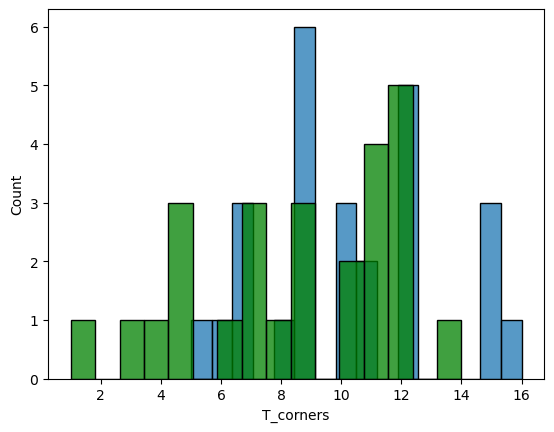

In [21]:
sns.histplot(data=mnc.T_corners, bins=16)
sns.histplot(data=asv.T_corners, bins=16, color='green')
plt.show()


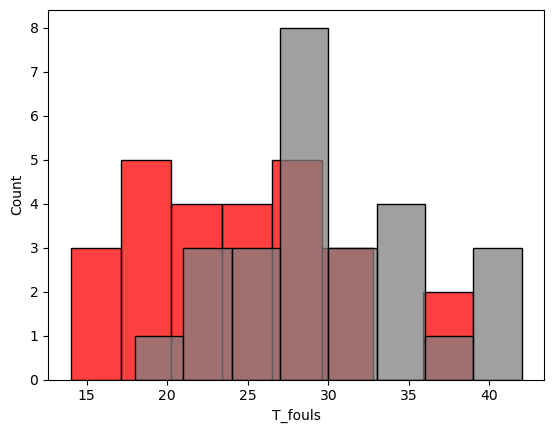

In [13]:
sns.histplot(data=mnc.T_fouls, bins=8, color='red')
sns.histplot(data=asv.T_fouls, bins=8, color='grey')
plt.show()


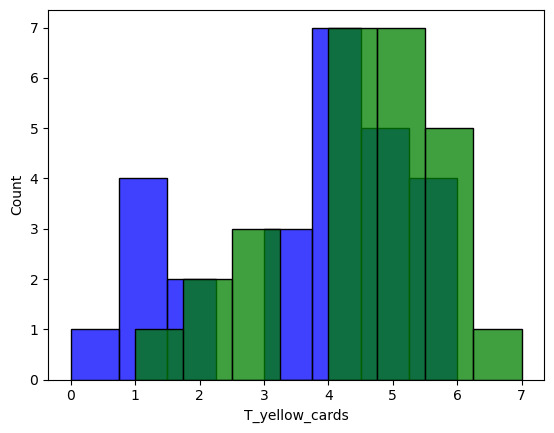

In [16]:
sns.histplot(data=mnc.T_yellow_cards, bins=8, color='blue')
sns.histplot(data=asv.T_yellow_cards, bins=8, color='green')
plt.show()
